### This notebook extract newly generated molecules after the DORAnet run: 

In [21]:
import os
import io
import json
import math
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, deque
from io import BytesIO
from IPython.display import display

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Draw, QED, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

from PIL import Image, ImageDraw, ImageFont

RDLogger.DisableLog('rdApp.*')

In [22]:
from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

In [23]:
fileNamePrefix = "RemdesivirOnly_gen2"

In [24]:
def canonSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

### generate `max_atoms` configuration

In [25]:
starterSMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@@H]1[C@H]([C@H]([C@](O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4'

mol = Chem.MolFromSmiles(starterSMILES)
counts = {"C": 0, "N": 0, "O": 0, "S": 0}

for atom in mol.GetAtoms():
    sym = atom.GetSymbol()
    if sym in counts:
        counts[sym] += 1

print("Atom counts:", counts)

max_atoms = {k: math.ceil(v * 1.5) for k, v in counts.items()}
print("Recommended max_atoms:", max_atoms)

Atom counts: {'C': 27, 'N': 6, 'O': 8, 'S': 0}
Recommended max_atoms: {'C': 41, 'N': 9, 'O': 12, 'S': 0}


### Discover All Starter Directories

In [26]:
doranetOutputDir = "doranet_output"
doranet_generations = 2

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

Output directory: doranet_output
Number of helpers to exclude: 33


In [27]:
# Automatically find all *_molecules.csv files in the current working directory
currentDir = os.getcwd()

allMoleculesCsvFiles = sorted(glob.glob(os.path.join(currentDir, "*_molecules.csv")))

print(f"Found {len(allMoleculesCsvFiles)} molecules CSV files in current directory")

# Parse discovered CSV files
discoveredCsvFiles = []

for csvPath in allMoleculesCsvFiles:
    fileName = os.path.basename(csvPath)
    dirName = fileName.replace('_molecules.csv', '')
    
    try:
        starterNum = int(dirName.replace('starter_', ''))
    except ValueError:
        starterNum = -1  # For non-standard naming

    discoveredCsvFiles.append({
        'dirName': dirName,
        'dirPath': currentDir,
        'csvPath': csvPath,
        'starterNum': starterNum
    })

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")

Found 1 molecules CSV files in current directory
Found 1 CSV files containing DORAnet generated molecules


### Extract the `DORAnet` starter molecule

In [28]:
user_starters = set()
starterReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        # Read only the SMILES and Is_Starter columns to save memory
        tempDF = pd.read_csv(
            fileInfo['csvPath'],
            usecols=['SMILES', 'Is_Starter']
        )
        starterSmiles = (
            tempDF[tempDF['Is_Starter'] == True]['SMILES']
            .dropna()
            .tolist()
        )
        user_starters.update(starterSmiles)

    except Exception as e:
        starterReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

if len(user_starters) == 0:
    raise ValueError("No starter molecules found across any CSV files!")

print(f"Number of unique starter molecules found: {len(user_starters)}")
for i, smi in enumerate(user_starters, 1):
    print(f"  Starter {i}: {smi}")

if starterReadErrors:
    print(f"\nFailed to read {len(starterReadErrors)} files:")
    for err in starterReadErrors:
        print(f"  {err['dirName']}: {err['error']}")

Number of unique starter molecules found: 1
  Starter 1: CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@@H]1[C@H]([C@H]([C@](O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4


### Read `reaction_strings` from the `DORAnet` generated `json` file

In [29]:
jsonFile = f"{fileNamePrefix}_network_pretreated.json"

with open(jsonFile, "r", encoding="utf-8") as f:
    reactionList = json.load(f)

def splitMoleculeString(moleculeString):
    if pd.isna(moleculeString) if hasattr(pd, 'isna') else moleculeString is None:
        return []
    return [mol for mol in str(moleculeString).split(".") if mol]

reactionRecords = []

for rxn in reactionList:
    parts = str(rxn).split(">")
    if len(parts) != 4:
        continue

    reactants, ruleName, metaBlock, products = parts
    metaParts      = (metaBlock.split("$") + [None, None, None, None])[:4]
    thermo, reactantStoich, productStoich, reactionType = metaParts

    reactantMols = splitMoleculeString(reactants.strip())
    productMols  = splitMoleculeString(products.strip())

    reactionRecords.append({
        "reactants"            : reactants.strip(),
        "products"             : products.strip(),
        "reactionString"       : f"{reactants.strip()} >> {products.strip()}",
        "ruleName"             : ruleName.strip(),
        "thermo"               : thermo,
        "reactantStoich"       : reactantStoich,
        "productStoich"        : productStoich,
        "reactionType"         : reactionType,
        "numReactantMolecules" : len(reactantMols),
        "numProductMolecules"  : len(productMols),
    })

reactionDF = pd.DataFrame(reactionRecords)

allReactantMols = reactionDF["reactants"].apply(splitMoleculeString).explode()
allProductMols  = reactionDF["products"].apply(splitMoleculeString).explode()

print(f"Total reactions                      : {len(reactionDF):,}")
print(f"Unique reactant strings              : {reactionDF['reactants'].nunique():,}")
print(f"Unique product strings               : {reactionDF['products'].nunique():,}")
print(f"Unique individual reactant molecules : {allReactantMols.nunique():,}")
print(f"Unique individual product molecules  : {allProductMols.nunique():,}")
print(f"Unique reaction rules                : {reactionDF['ruleName'].nunique():,}")
print(f"reactionType counts:")
print(reactionDF["reactionType"].value_counts(dropna=False).to_string())

reactionDF.to_csv("reactionDF.csv", index=False)
reactionDF

Total reactions                      : 78,117
Unique reactant strings              : 5,251
Unique product strings               : 67,344
Unique individual reactant molecules : 272
Unique individual product molecules  : 40,203
Unique reaction rules                : 315
reactionType counts:
reactionType
Enzymatic    78117


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@]1(C)O[C@...,CCCC(CC)OC(=O)[C@H](C)N[P@](=O)(OC[C@]1(C)O[C@...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@]1(C)O[C@...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
1,CCC(COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#...,CCC(COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#...,CCC(COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
2,CCC(CC)COC(=O)CCC(CC)COC(=O)[C@H](C)N[P@](=O)(...,CCC(C)COC(=O)CCC(CC)COC(=O)[C@H](C)N[P@](=O)(O...,CCC(CC)COC(=O)CCC(CC)COC(=O)[C@H](C)N[P@](=O)(...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
3,CCC(CCC(=O)O)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1...,CCC(CCC(=O)O)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1...,CCC(CCC(=O)O)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1...,rule1165_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@@](C)(N[P@](=O)(OC[C@H]1O[C@@...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
...,...,...,...,...,...,...,...,...,...,...
78112,CCC(C)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,CCCOC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#N)...,CCC(C)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
78113,CCc1cc([C@]2(C#N)O[C@H](CO[P@@](=O)(N[C@@H](C)...,CCc1cc([C@]2(C#N)O[C@H](CO[P@@](=O)(N[C@@H](C)...,CCc1cc([C@]2(C#N)O[C@H](CO[P@@](=O)(N[C@@H](C)...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
78114,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,rule0951_1,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3
78115,CCCCOC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#N...,CCCCOC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#N...,CCCCOC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#N...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1


### Identify `generated` compounds with `substructure` match with `starter` compound

In [30]:
DORAnet_CoFactors = "/users/sghosh6/DTRA_project/MACAW/doranet/scripts/doranet_all_cofactors.tsv"

_cofactorTable = pd.read_csv(DORAnet_CoFactors, sep="\t")
_cofactorTable.columns = [col.lstrip("#").strip() for col in _cofactorTable.columns]

COFACTOR_SMILES = [
    Chem.MolToSmiles(mol)
    for smi in _cofactorTable["SMILES"].dropna()
    if (mol := Chem.MolFromSmiles(str(smi))) is not None
]
print(f"{len(COFACTOR_SMILES)} Co-factors for enzymatic reactions loaded from DORAnet database.")

46 Co-factors for enzymatic reactions loaded from DORAnet database.


In [32]:
PHYSICOCHEMICAL_CUTOFFS = {
    "mw_max"  : 700.0,
    "tpsa_max": 200.0,
    "hbd_max" : 7,
    "qed_min" : 0.10,
}


def buildCofactorExclusionSet(rawSmilesList):
    exclusionSet = set()
    for smi in rawSmilesList:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            exclusionSet.add(Chem.MolToSmiles(mol))
        else:
            print(f"  Warning: could not parse cofactor SMILES: {smi}")
    print(f"Cofactor exclusion set built: {len(exclusionSet)} entries resolved.")
    return exclusionSet


def isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, cutoffs):
    if mol is None:
        return True
    if canonSmi in cofactorExclusionSet:
        return True
    mw   = Descriptors.MolWt(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    if mw > cutoffs["mw_max"] or tpsa > cutoffs["tpsa_max"] or hbd > cutoffs["hbd_max"]:
        return True
    qed = QED.qed(mol)
    if qed < cutoffs["qed_min"]:
        return True
    return False


def hasStarterScaffold(mol, starterMols):
    if mol is None:
        return False, None
    for starterCanon, starterMol in starterMols:
        if mol.HasSubstructMatch(starterMol):
            return True, starterCanon
    return False, None


def buildStarterDerivedSet(reactionDF, starterMols, canonStarterSet,
                           canonHelperSet, cofactorExclusionSet, cutoffs):
    molToReactionIdxs = defaultdict(list)
    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            molToReactionIdxs[canonSmiles(smi)].append(idx)

    starterDerivedSet = {canonSmi: canonSmi for canonSmi, _ in starterMols}
    queue   = deque(canonStarterSet)
    visited = set(canonStarterSet)

    while queue:
        currentCanon = queue.popleft()
        for rxnIdx in molToReactionIdxs.get(currentCanon, []):
            row = reactionDF.loc[rxnIdx]
            for productSmi in splitMoleculeString(row["products"]):
                productCanon = canonSmiles(productSmi)

                if productCanon in visited:
                    continue
                visited.add(productCanon)

                if productCanon in canonHelperSet:
                    continue

                productMol = Chem.MolFromSmiles(str(productSmi))

                if isCofactorOrEndogenous(productMol, productCanon,
                                          cofactorExclusionSet, cutoffs):
                    continue

                isDerivative, matchedStarter = hasStarterScaffold(productMol, starterMols)
                if isDerivative:
                    starterDerivedSet[productCanon] = matchedStarter
                    queue.append(productCanon)

    return starterDerivedSet


COFACTOR_EXCLUSION_SET = buildCofactorExclusionSet(COFACTOR_SMILES)

starterMols = [
    (canonSmiles(smi), Chem.MolFromSmiles(str(smi)))
    for smi in user_starters
    if Chem.MolFromSmiles(str(smi)) is not None
]
canonStarterSet = {s for s, _ in starterMols}
canonHelperSet  = {canonSmiles(s) for s in helpersToExclude}

print("Running forward BFS tracing through reaction network...")
starterDerivedSet = buildStarterDerivedSet(
    reactionDF,
    starterMols,
    canonStarterSet,
    canonHelperSet,
    cofactorExclusionSet = COFACTOR_EXCLUSION_SET,
    cutoffs              = PHYSICOCHEMICAL_CUTOFFS,
)
print(f"Starter-derived molecules found (including starters): {len(starterDerivedSet):,}")

uniqueProductMolsList = allProductMols.dropna().unique().tolist()

productRecords         = []
excludedCofactorSmiles = []
excluded_helper        = 0
excluded_starter       = 0
excluded_cofactor      = 0
excluded_nonstarter    = 0

for smi in uniqueProductMolsList:
    mol      = Chem.MolFromSmiles(str(smi))
    canonSmi = Chem.MolToSmiles(mol) if mol else None

    if canonSmi is None:
        continue
    if canonSmi in canonHelperSet:
        excluded_helper += 1
        continue
    if canonSmi in canonStarterSet:
        excluded_starter += 1
        continue
    if isCofactorOrEndogenous(mol, canonSmi, COFACTOR_EXCLUSION_SET, PHYSICOCHEMICAL_CUTOFFS):
        excluded_cofactor += 1
        excludedCofactorSmiles.append(canonSmi)
        continue
    if canonSmi not in starterDerivedSet:
        excluded_nonstarter += 1
        continue

    matchedRaw             = starterDerivedSet.get(canonSmi)
    starterCanonicalSmiles = canonSmiles(matchedRaw) if matchedRaw else None

    productRecords.append({
        "starter_Canonical_SMILES" : starterCanonicalSmiles,
        "Canonical_SMILES"         : canonSmi,
        "molecularFormula"         : rdMolDescriptors.CalcMolFormula(mol),
        "molecularWeight"          : round(Descriptors.MolWt(mol), 4),
        "numHeavyAtoms"            : mol.GetNumHeavyAtoms(),
    })

generatedCompoundsDF_raw = (
    pd.DataFrame(productRecords)
    .sort_values(["starter_Canonical_SMILES", "molecularWeight"], ascending=[True, True])
    .reset_index(drop=True)
)

nBeforeDedup = len(generatedCompoundsDF_raw)

generatedCompoundsDF = (
    generatedCompoundsDF_raw
    .drop_duplicates(subset="Canonical_SMILES", keep="first")
    .reset_index(drop=True)
)

nAfterDedup = len(generatedCompoundsDF)

generatedCompoundsCsvPath = f"{fileNamePrefix}_generated_compounds.csv"
generatedCompoundsDF.to_csv(generatedCompoundsCsvPath, index=False)

print(f"Unique product molecules total        : {len(uniqueProductMolsList):,}")
print(f"Excluded as helpers                   : {excluded_helper:,}")
print(f"Excluded as starters                  : {excluded_starter:,}")
print(f"Excluded as cofactors / endogenous    : {excluded_cofactor:,}")
print(f"Excluded as non-starter derivatives   : {excluded_nonstarter:,}")
print(f"Compounds before deduplication        : {nBeforeDedup:,}")
print(f"Compounds after deduplication         : {nAfterDedup:,}")
print(f"Duplicates removed                    : {nBeforeDedup - nAfterDedup:,}")
print(f"\nDerivatives per starter (post-dedup):")
print(generatedCompoundsDF["starter_Canonical_SMILES"].value_counts(dropna=False).to_string())
print(f"\nSaved to: {generatedCompoundsCsvPath}")

generatedCompoundsDF

Cofactor exclusion set built: 43 entries resolved.
Running forward BFS tracing through reaction network...
Starter-derived molecules found (including starters): 288
Unique product molecules total        : 40,203
Excluded as helpers                   : 13
Excluded as starters                  : 1
Excluded as cofactors / endogenous    : 32,500
Excluded as non-starter derivatives   : 7,402
Compounds before deduplication        : 287
Compounds after deduplication         : 287
Duplicates removed                    : 0

Derivatives per starter (post-dedup):
starter_Canonical_SMILES
CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#N)(c2ccc3c(N)ncnn23)[C@H](O)[C@@H]1O)Oc1ccccc1    287

Saved to: RemdesivirOnly_gen2_generated_compounds.csv


,starter_Canonical_SMILES,Canonical_SMILES,molecularFormula,molecularWeight,numHeavyAtoms
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C28H37N6O8P,616.612,43
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C28H37N6O8P,616.612,43
2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N(C)[P@](=O)(OC[C@H]1O[C...,C28H37N6O8P,616.612,43
3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C29H39N6O8P,630.639,44
4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](CC)N[P@](=O)(OC[C@H]1O[C@@...,C29H39N6O8P,630.639,44
...,...,...,...,...,...
282,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N(c1ccccc1)[P@](=O)(OC[C...,C34H41N6O8P,692.710,49
283,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C34H41N6O8P,692.710,49
284,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C34H41N6O8P,692.710,49
285,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C34H41N6O8P,692.710,49


### Select `structurally` diverse compounds from the generated compound list

### Visualize `product` compounds

Selecting structurally diverse compounds via MaxMinPicker...
Selected 18 compounds from 287 total.
Row 01 saved: RemdesivirOnly_gen2_row01.png  |  RemdesivirOnly_gen2_row01.pdf
Row 02 saved: RemdesivirOnly_gen2_row02.png  |  RemdesivirOnly_gen2_row02.pdf
Row 03 saved: RemdesivirOnly_gen2_row03.png  |  RemdesivirOnly_gen2_row03.pdf
Row 04 saved: RemdesivirOnly_gen2_row04.png  |  RemdesivirOnly_gen2_row04.pdf
Row 05 saved: RemdesivirOnly_gen2_row05.png  |  RemdesivirOnly_gen2_row05.pdf
Row 06 saved: RemdesivirOnly_gen2_row06.png  |  RemdesivirOnly_gen2_row06.pdf

6 row figures saved individually at 600 DPI.


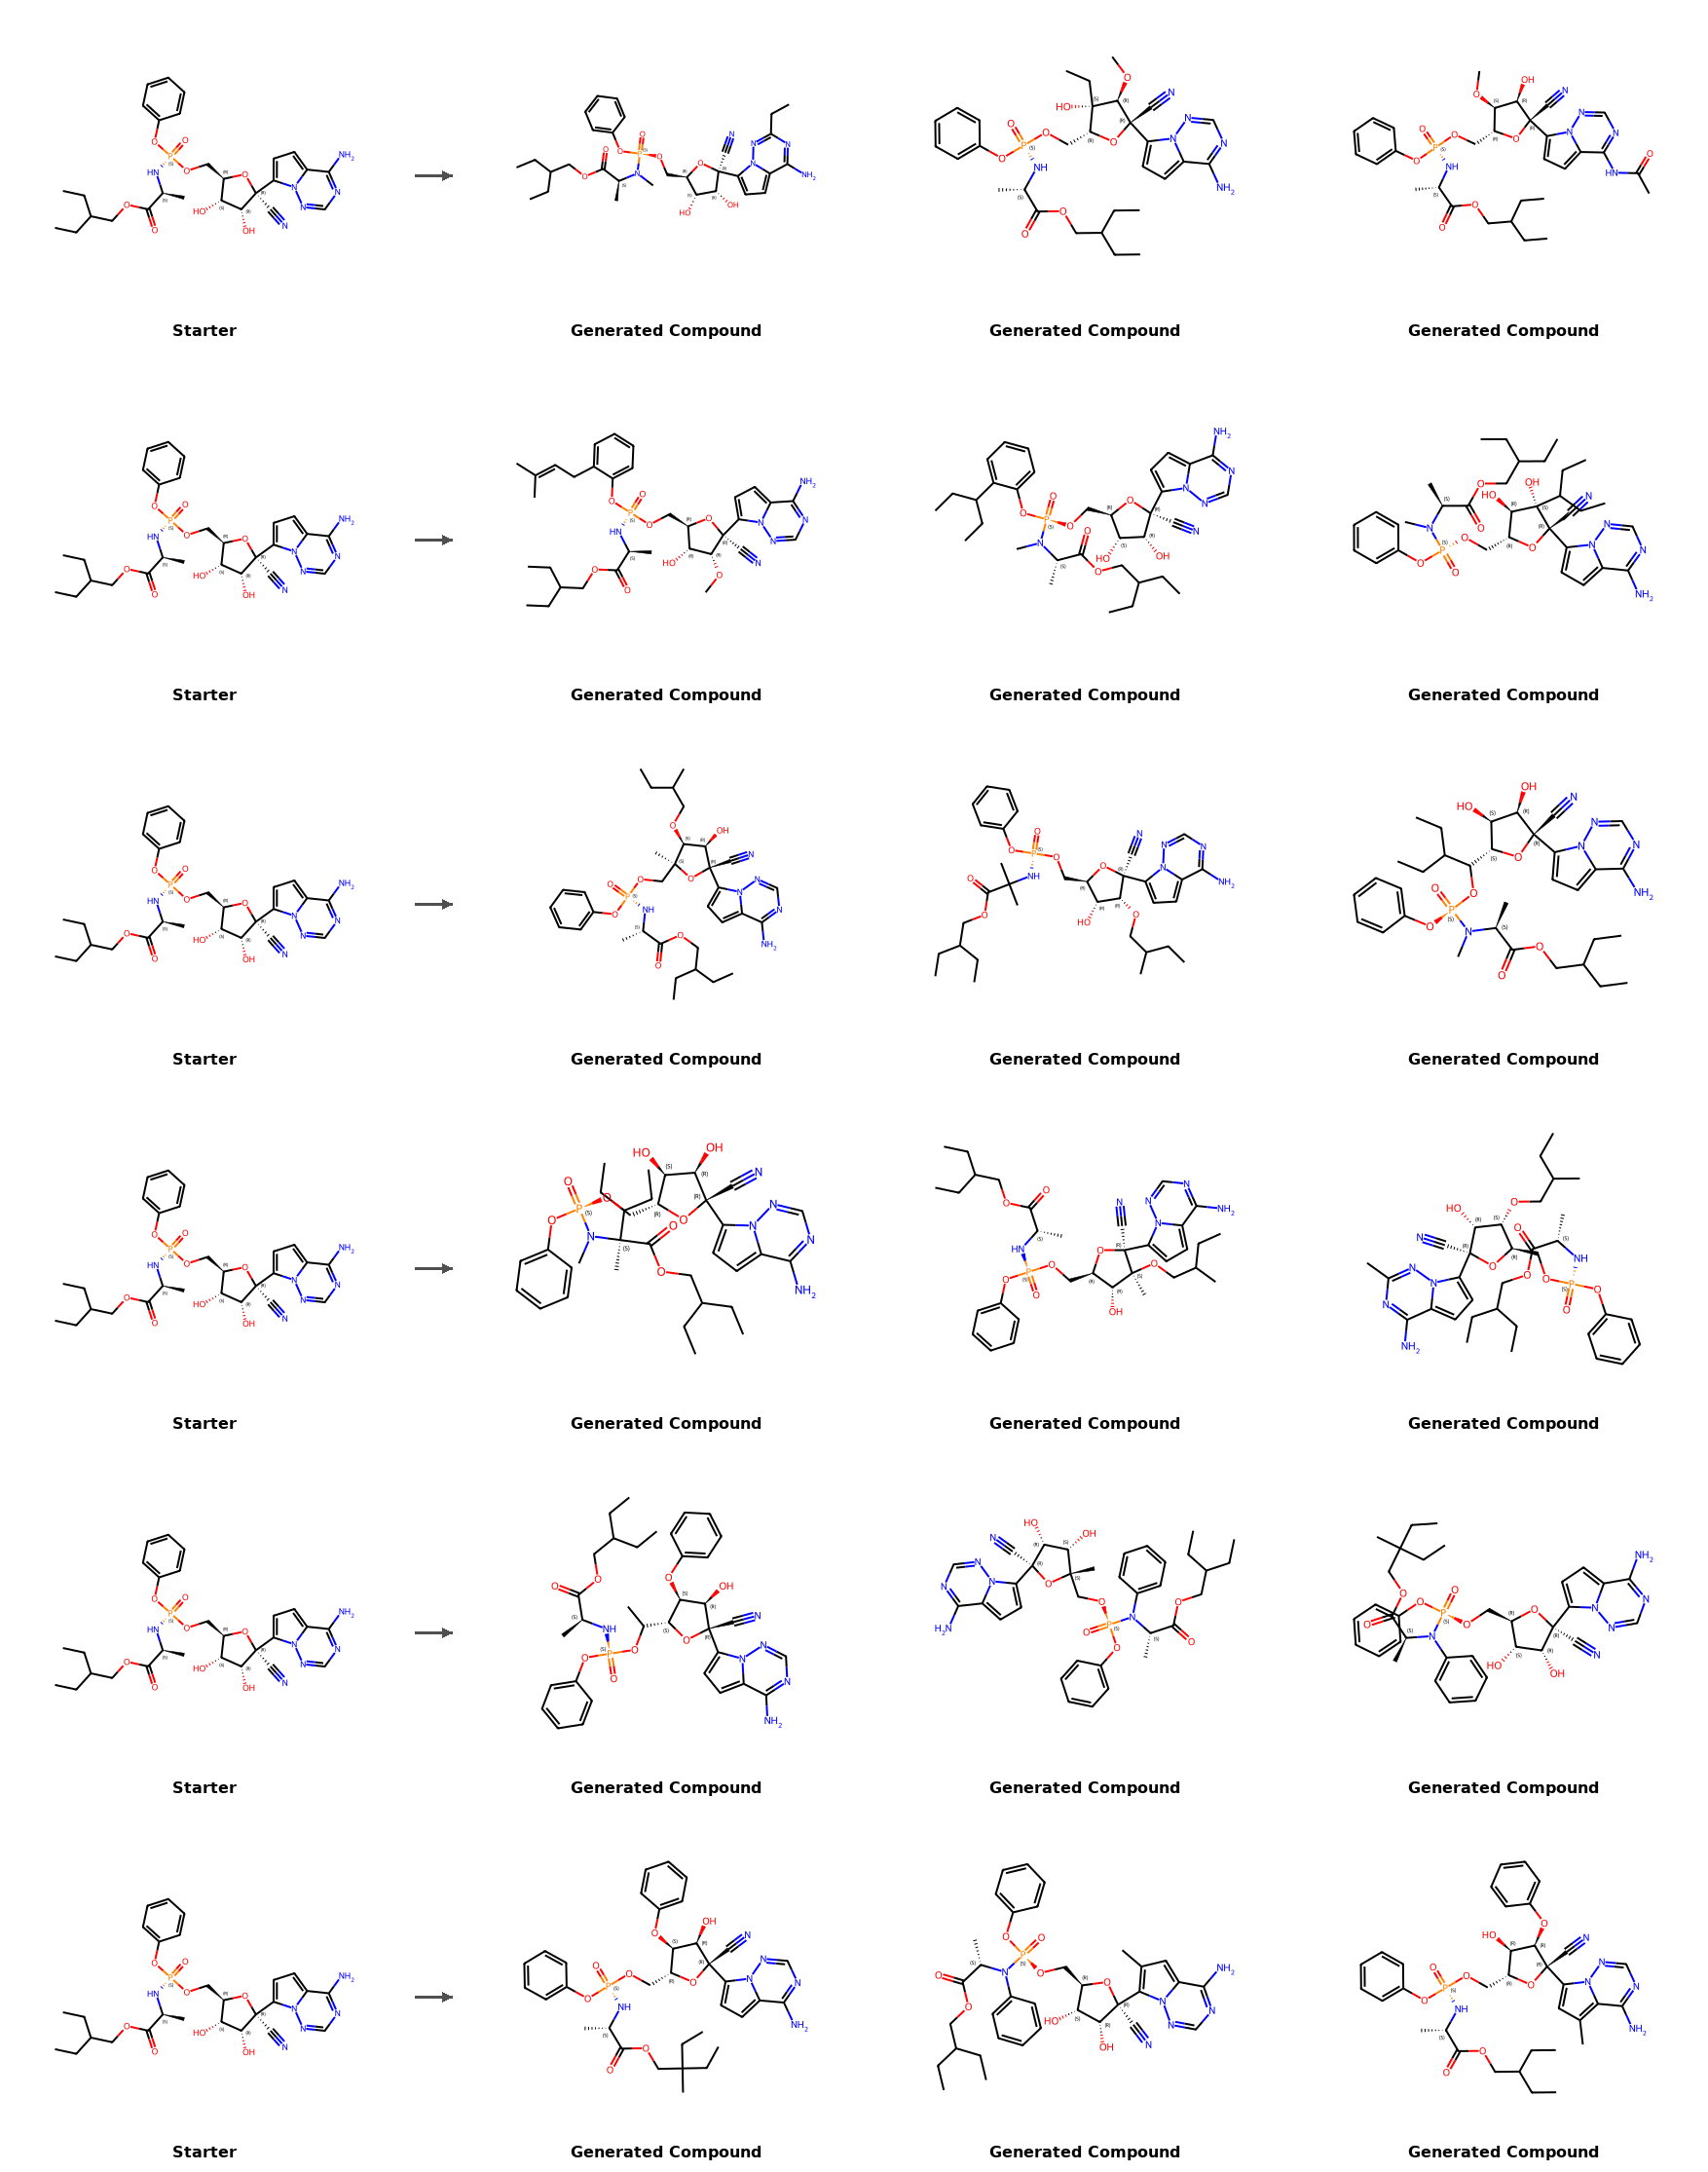

In [17]:
nTargetsTotal   = 18
nTargetsPerRow  = 3
molCellW        = 420
molCellH        = 320
labelH          = 40
arrowZoneW      = 54
targetGap       = 10
dpi             = 600

white           = (255, 255, 255)
black           = (0,   0,   0  )
arrowColor      = (80,  80,  80 )

fontBoldPath    = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"


def loadFont(path, size):
    try:
        return ImageFont.truetype(path, size)
    except Exception:
        return ImageFont.load_default()


def renderMolToPil(mol, w, h):
    try:
        drawer = rdMolDraw2D.MolDraw2DCairo(w, h)
        drawer.drawOptions().addStereoAnnotation = True
        drawer.drawOptions().padding = 0.12
        rdMolDraw2D.PrepareMolForDrawing(mol)
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        return Image.open(io.BytesIO(drawer.GetDrawingText())).convert("RGB")
    except Exception:
        from rdkit.Chem import Draw
        return Draw.MolToImage(mol, size=(w, h))


def selectDiverseIdxs(smilesList, nSelect, seed=42):
    fps, validIdxs = [], []
    for i, smi in enumerate(smilesList):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
            validIdxs.append(i)

    nSelect = min(nSelect, len(fps))

    def distFunc(i, j, fps=fps):
        return 1.0 - DataStructs.TanimotoSimilarity(fps[i], fps[j])

    picker      = MaxMinPicker()
    pickedLocal = list(picker.LazyPick(distFunc, len(fps), nSelect, seed=seed))
    return sorted([validIdxs[k] for k in pickedLocal])


def drawMolCell(mol, cellW, cellH, molH, label, fontBold):
    cell = Image.new("RGB", (cellW, cellH), white)
    ctx  = ImageDraw.Draw(cell)

    if mol is not None:
        molImg = renderMolToPil(mol, cellW - 16, molH - 8)
        cell.paste(molImg, (8, 4))

    bb  = ctx.textbbox((0, 0), label, font=fontBold)
    lW  = bb[2] - bb[0]
    ctx.text(((cellW - lW) // 2, molH + 10), label, fill=black, font=fontBold)
    return cell


def pasteArrow(canvas, x, y, length=34, color=arrowColor):
    d = ImageDraw.Draw(canvas)
    d.line([(x, y), (x + length, y)], fill=color, width=3)
    headL, headW = 10, 5
    d.polygon([
        (x + length,          y),
        (x + length - headL,  y - headW),
        (x + length - headL,  y + headW),
    ], fill=color)


def buildRowCanvas(starterMol, targetMols, fontBold):
    cellH = molCellH + labelH
    rowW  = (molCellW + arrowZoneW +
             nTargetsPerRow * molCellW +
             (nTargetsPerRow - 1) * targetGap)

    canvas      = Image.new("RGB", (rowW, cellH), white)
    starterCell = drawMolCell(starterMol, molCellW, cellH, molCellH, "Starter", fontBold)
    canvas.paste(starterCell, (0, 0))

    pasteArrow(canvas, x=molCellW + 6, y=cellH // 2, length=arrowZoneW - 16)

    for tIdx, targetMol in enumerate(targetMols):
        cellX      = molCellW + arrowZoneW + tIdx * (molCellW + targetGap)
        targetCell = drawMolCell(targetMol, molCellW, cellH, molCellH,
                                 "Generated Compound", fontBold)
        canvas.paste(targetCell, (cellX, 0))

    return canvas


print("Selecting structurally diverse compounds via MaxMinPicker...")
diverseIdxs = selectDiverseIdxs(
    generatedCompoundsDF["Canonical_SMILES"].tolist(),
    nTargetsTotal,
)
selectedDF = (
    generatedCompoundsDF
    .iloc[diverseIdxs]
    .copy()
    .reset_index(drop=True)
)
print(f"Selected {len(selectedDF)} compounds from {len(generatedCompoundsDF):,} total.")

rows = []
for starterSmi, grp in selectedDF.groupby("starter_Canonical_SMILES", sort=False):
    targets = grp["Canonical_SMILES"].tolist()
    for i in range(0, len(targets), nTargetsPerRow):
        batch = targets[i : i + nTargetsPerRow]
        while len(batch) < nTargetsPerRow:
            batch.append(None)
        rows.append({"starterSmi": starterSmi, "targets": batch})

fontBold    = loadFont(fontBoldPath, 16)
rowCanvases = []

for rowIdx, rowData in enumerate(rows):
    starterMol = Chem.MolFromSmiles(rowData["starterSmi"])
    targetMols = [
        Chem.MolFromSmiles(smi) if smi else None
        for smi in rowData["targets"]
    ]

    rowCanvas = buildRowCanvas(starterMol, targetMols, fontBold)
    rowCanvases.append(rowCanvas)

    pngPath = f"{fileNamePrefix}_row{rowIdx + 1:02d}.png"
    pdfPath = f"{fileNamePrefix}_row{rowIdx + 1:02d}.pdf"
    rowCanvas.save(pngPath, format="PNG", dpi=(dpi, dpi))
    rowCanvas.save(pdfPath, format="PDF", resolution=dpi)
    print(f"Row {rowIdx + 1:02d} saved: {pngPath}  |  {pdfPath}")

rowGap     = 14
rowCellH   = molCellH + labelH
fullW      = rowCanvases[0].width
fullH      = len(rowCanvases) * rowCellH + (len(rowCanvases) - 1) * rowGap
fullCanvas = Image.new("RGB", (fullW, fullH), white)

for i, rc in enumerate(rowCanvases):
    fullCanvas.paste(rc, (0, i * (rowCellH + rowGap)))

print(f"\n{len(rows)} row figures saved individually at {dpi} DPI.")
fullCanvas

### Print `pathway` level details

In [18]:
def buildReactionIndex(reactionDF, canonHelperSet):
    molToRxnIdxs = defaultdict(list)
    rxnProducts  = {}

    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            c = canonSmiles(smi)
            if c not in canonHelperSet:
                molToRxnIdxs[c].append(idx)

        rxnProducts[idx] = frozenset(
            canonSmiles(s) for s in splitMoleculeString(row["products"])
            if canonSmiles(s) not in canonHelperSet
        )

    return molToRxnIdxs, rxnProducts


def countChainsToTargets(starterCanon, targetCanonSet, molToRxnIdxs,
                         rxnProducts, starterMols, maxDepth=3):
    scaffoldCache = {}

    def isScaffoldBearing(canonSmi):
        if canonSmi not in scaffoldCache:
            mol = Chem.MolFromSmiles(canonSmi)
            scaffoldCache[canonSmi] = (
                mol is not None and
                any(mol.HasSubstructMatch(starterMol) for _, starterMol in starterMols)
            )
        return scaffoldCache[canonSmi]

    def productsHaveScaffold(products):
        return any(isScaffoldBearing(m) for m in products)

    counts        = defaultdict(lambda: defaultdict(int))
    queue         = deque()
    statesVisited = 0

    for rxnIdx in molToRxnIdxs.get(starterCanon, []):
        products = rxnProducts[rxnIdx]
        chain    = (rxnIdx,)

        for target in products & targetCanonSet:
            counts[target][1] += 1

        if maxDepth > 1:
            queue.append((chain, products, frozenset({rxnIdx})))

    while queue:
        chain, availMols, visitedRxns = queue.popleft()
        statesVisited += 1
        depth = len(chain)

        if depth >= maxDepth:
            continue

        for mol in availMols:
            for rxnIdx in molToRxnIdxs.get(mol, []):
                if rxnIdx in visitedRxns:
                    continue

                products  = rxnProducts[rxnIdx]
                newChain  = chain + (rxnIdx,)
                newDepth  = len(newChain)

                for target in products & targetCanonSet:
                    counts[target][newDepth] += 1

                if newDepth < maxDepth:
                    newState = (newChain, products, visitedRxns | {rxnIdx})
                    if productsHaveScaffold(products):
                        queue.appendleft(newState)
                    else:
                        queue.append(newState)

    return counts, statesVisited


print("Building reaction index...")
molToRxnIdxs, rxnProducts = buildReactionIndex(reactionDF, canonHelperSet)
print(f"Indexed {len(molToRxnIdxs):,} unique non-helper reactant molecules.")
print(f"Indexed {len(rxnProducts):,} reactions.\n")

totalCompounds = len(generatedCompoundsDF)
print(f"Total compounds after deduplication (generatedCompoundsDF): {totalCompounds:,}\n")

summaryRecords     = []
perStarterSummary  = []

for starterSmi, group in generatedCompoundsDF.groupby("starter_Canonical_SMILES"):
    targetCanonSet  = set(group["Canonical_SMILES"].tolist())
    nTargets        = len(targetCanonSet)

    print(f"Starter : {starterSmi[:70]}")
    print(f"  Compounds from this starter  : {nTargets:,}")

    counts, statesVisited = countChainsToTargets(
        starterSmi,
        targetCanonSet,
        molToRxnIdxs,
        rxnProducts,
        starterMols = starterMols,
        maxDepth    = doranet_generations,
    )

    nWithPath    = sum(1 for t in targetCanonSet if counts.get(t))
    nWithoutPath = nTargets - nWithPath
    coverage     = nWithPath / nTargets * 100 if nTargets > 0 else 0.0

    print(f"  BFS states explored          : {statesVisited:,}")
    print(f"  With atlest one pathway              : {nWithPath:,}  ({coverage:.1f}%)")
    print(f"  With zero pathways           : {nWithoutPath:,}")
    print()

    perStarterSummary.append({
        "starter_Canonical_SMILES" : starterSmi,
        "total_compounds"          : nTargets,
        "compounds_with_pathway"   : nWithPath,
        "compounds_without_pathway": nWithoutPath,
        "pathway_coverage_pct"     : round(coverage, 2),
    })

    for _, row in group.iterrows():
        targetSmi    = row["Canonical_SMILES"]
        targetCounts = counts.get(targetSmi, {})
        n1 = targetCounts.get(1, 0)
        n2 = targetCounts.get(2, 0)
        n3 = targetCounts.get(3, 0)

        summaryRecords.append({
            "starter_Canonical_SMILES" : starterSmi,
            "Canonical_SMILES"         : targetSmi,
            "1step_pathways"           : n1,
            "2step_pathways"           : n2,
            "3step_pathways"           : n3,
            "total_pathways"           : n1 + n2 + n3,
        })

pathSummaryDF = (
    pd.DataFrame(summaryRecords)
    .sort_values(
        ["starter_Canonical_SMILES", "total_pathways"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

perStarterSummaryDF = pd.DataFrame(perStarterSummary)

nZero    = (pathSummaryDF["total_pathways"] == 0).sum()
nNonZero = (pathSummaryDF["total_pathways"] >  0).sum()


if nZero > 0:
    print(f"\n  Note: {nZero} zero-pathway compounds persist after exhaustive BFS.")
    print(f"  This indicates a canonicalization mismatch between")
    print(f"  buildStarterDerivedSet and countChainsToTargets.")

pathSummaryDF

Building reaction index...
Indexed 263 unique non-helper reactant molecules.
Indexed 78,117 reactions.

Total compounds after deduplication (generatedCompoundsDF): 287

Starter : CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#N)(c2ccc3c(N)ncnn23)[
  Compounds from this starter  : 287
  BFS states explored          : 366
  With atlest one pathway              : 287  (100.0%)
  With zero pathways           : 0



,starter_Canonical_SMILES,Canonical_SMILES,1step_pathways,2step_pathways,3step_pathways,total_pathways
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,1,80,0,81
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,1,80,0,81
2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCCO[C@@H]1[C@H](O)[C@@H](CO[P@@](=O)(N[C@@H]...,0,80,0,80
3,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCCO[C@H]1[C@@H](O)[C@](C#N)(c2ccc3c(N)ncnn23...,0,80,0,80
4,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(C)CO[C@@H]1[C@H](O)[C@@H](CO[P@@](=O)(N[C@...,0,80,0,80
...,...,...,...,...,...,...
282,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@...,0,2,0,2
283,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(C)CO[C@@H]1[C@H](O)[C@@H](CO[P@@](=O)(N[C@...,0,2,0,2
284,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0,2,0,2
285,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0,2,0,2


### Visualize `starter → product` reaction pathways from the network

Searching for 1-step, 2-step, and 3-step pathway chains...
  1-step pathways found: 3
  2-step pathways found: 3
  3-step pathways found: 3
Saved: RemdesivirOnly_gen2_step1_pathway1.png  |  RemdesivirOnly_gen2_step1_pathway1.pdf


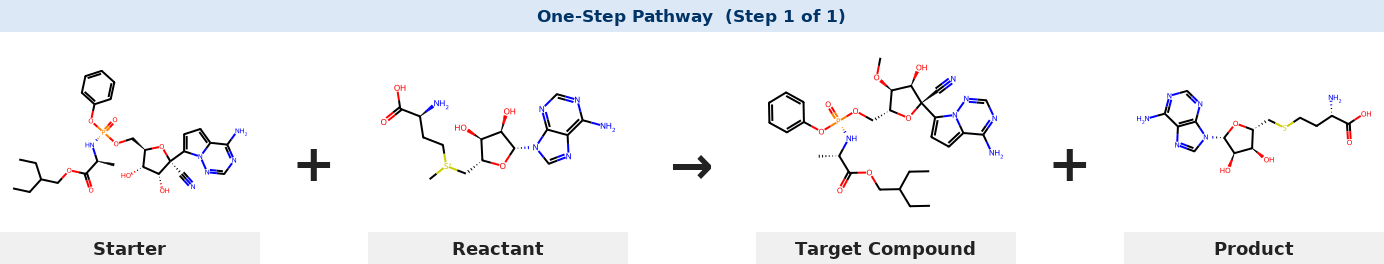

Saved: RemdesivirOnly_gen2_step1_pathway2.png  |  RemdesivirOnly_gen2_step1_pathway2.pdf


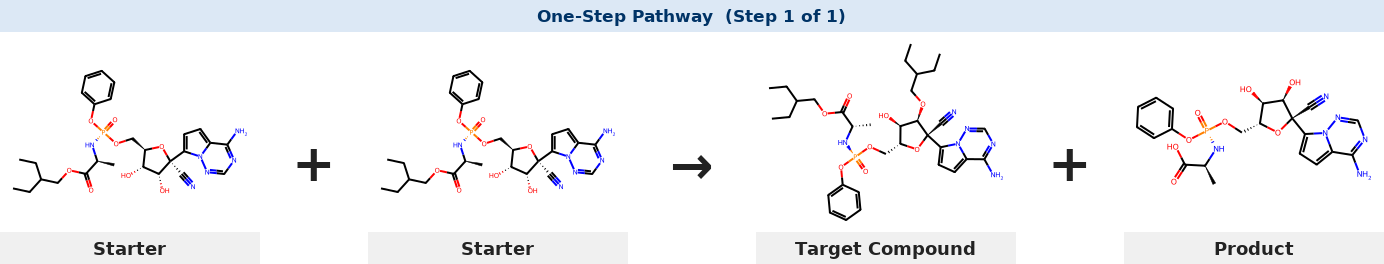

Saved: RemdesivirOnly_gen2_step1_pathway3.png  |  RemdesivirOnly_gen2_step1_pathway3.pdf


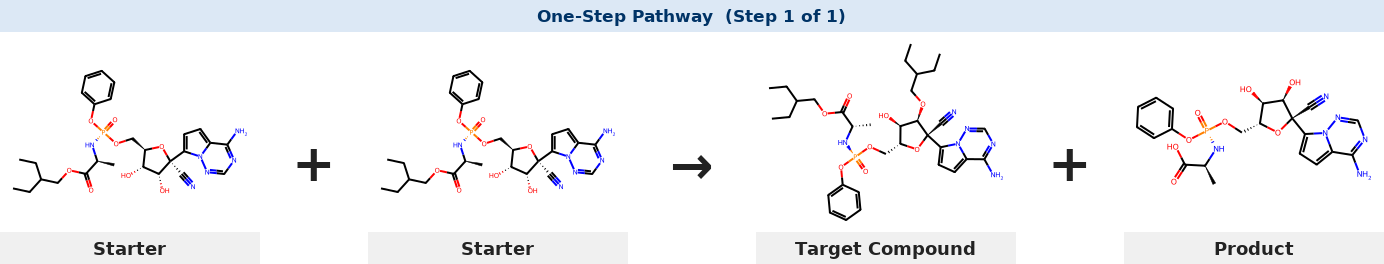

Saved: RemdesivirOnly_gen2_step2_pathway1.png  |  RemdesivirOnly_gen2_step2_pathway1.pdf


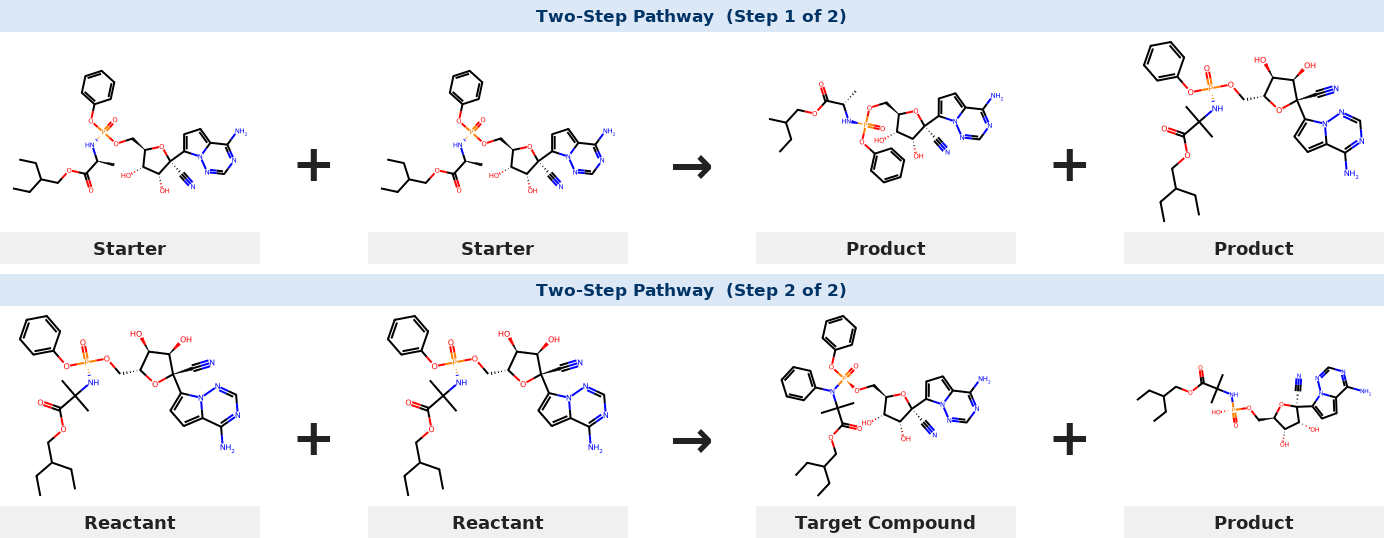

Saved: RemdesivirOnly_gen2_step2_pathway2.png  |  RemdesivirOnly_gen2_step2_pathway2.pdf


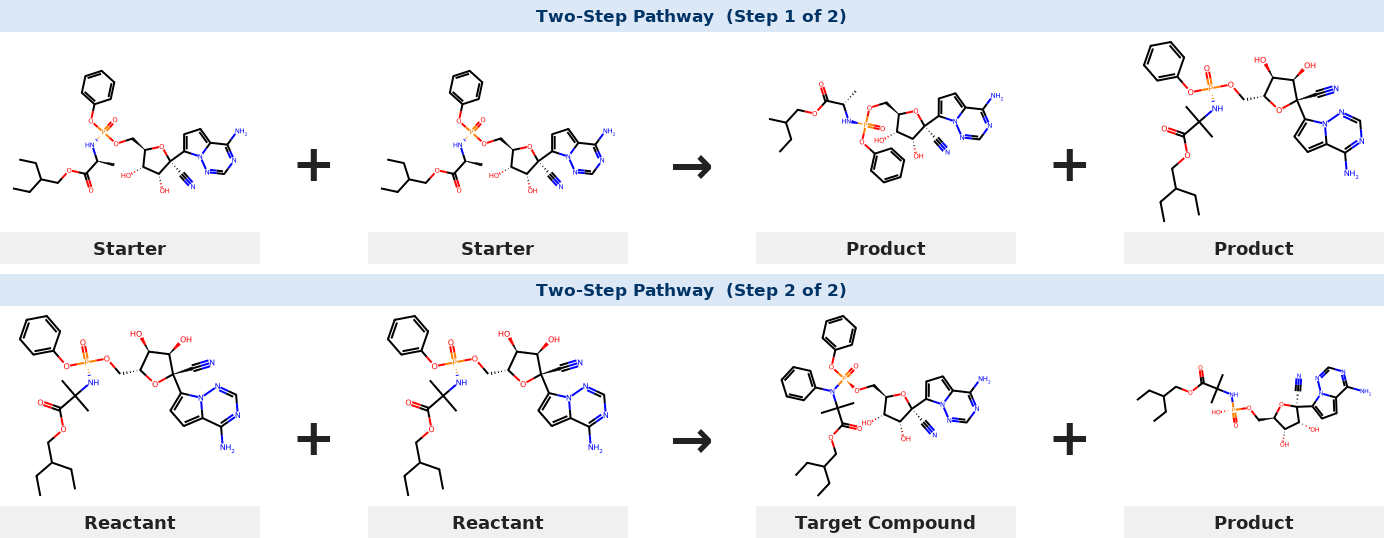

Saved: RemdesivirOnly_gen2_step2_pathway3.png  |  RemdesivirOnly_gen2_step2_pathway3.pdf


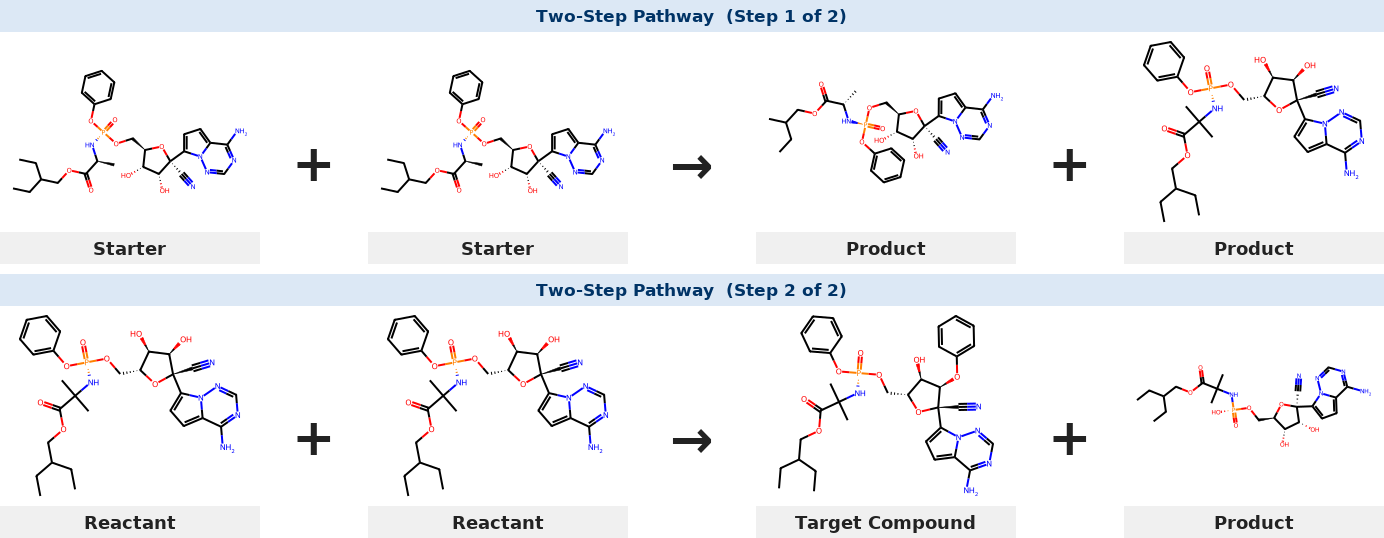

Saved: RemdesivirOnly_gen2_step3_pathway1.png  |  RemdesivirOnly_gen2_step3_pathway1.pdf


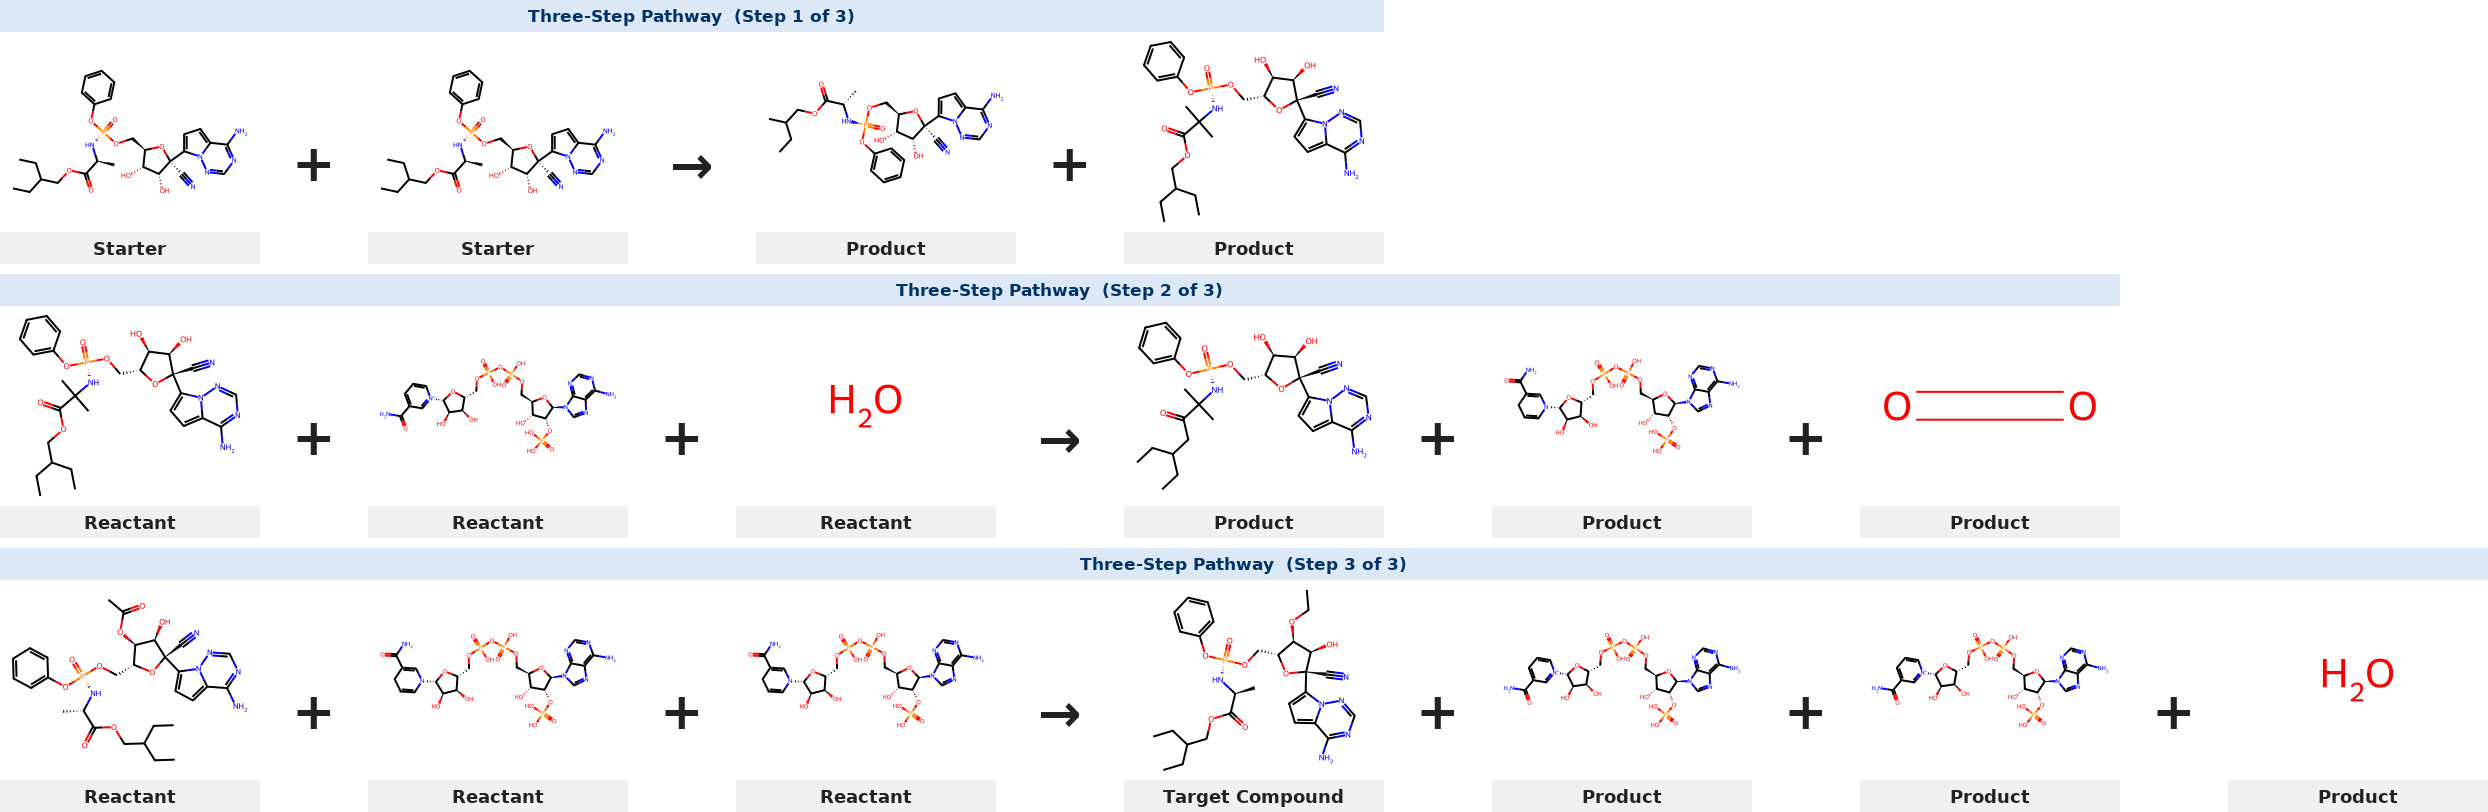

Saved: RemdesivirOnly_gen2_step3_pathway2.png  |  RemdesivirOnly_gen2_step3_pathway2.pdf


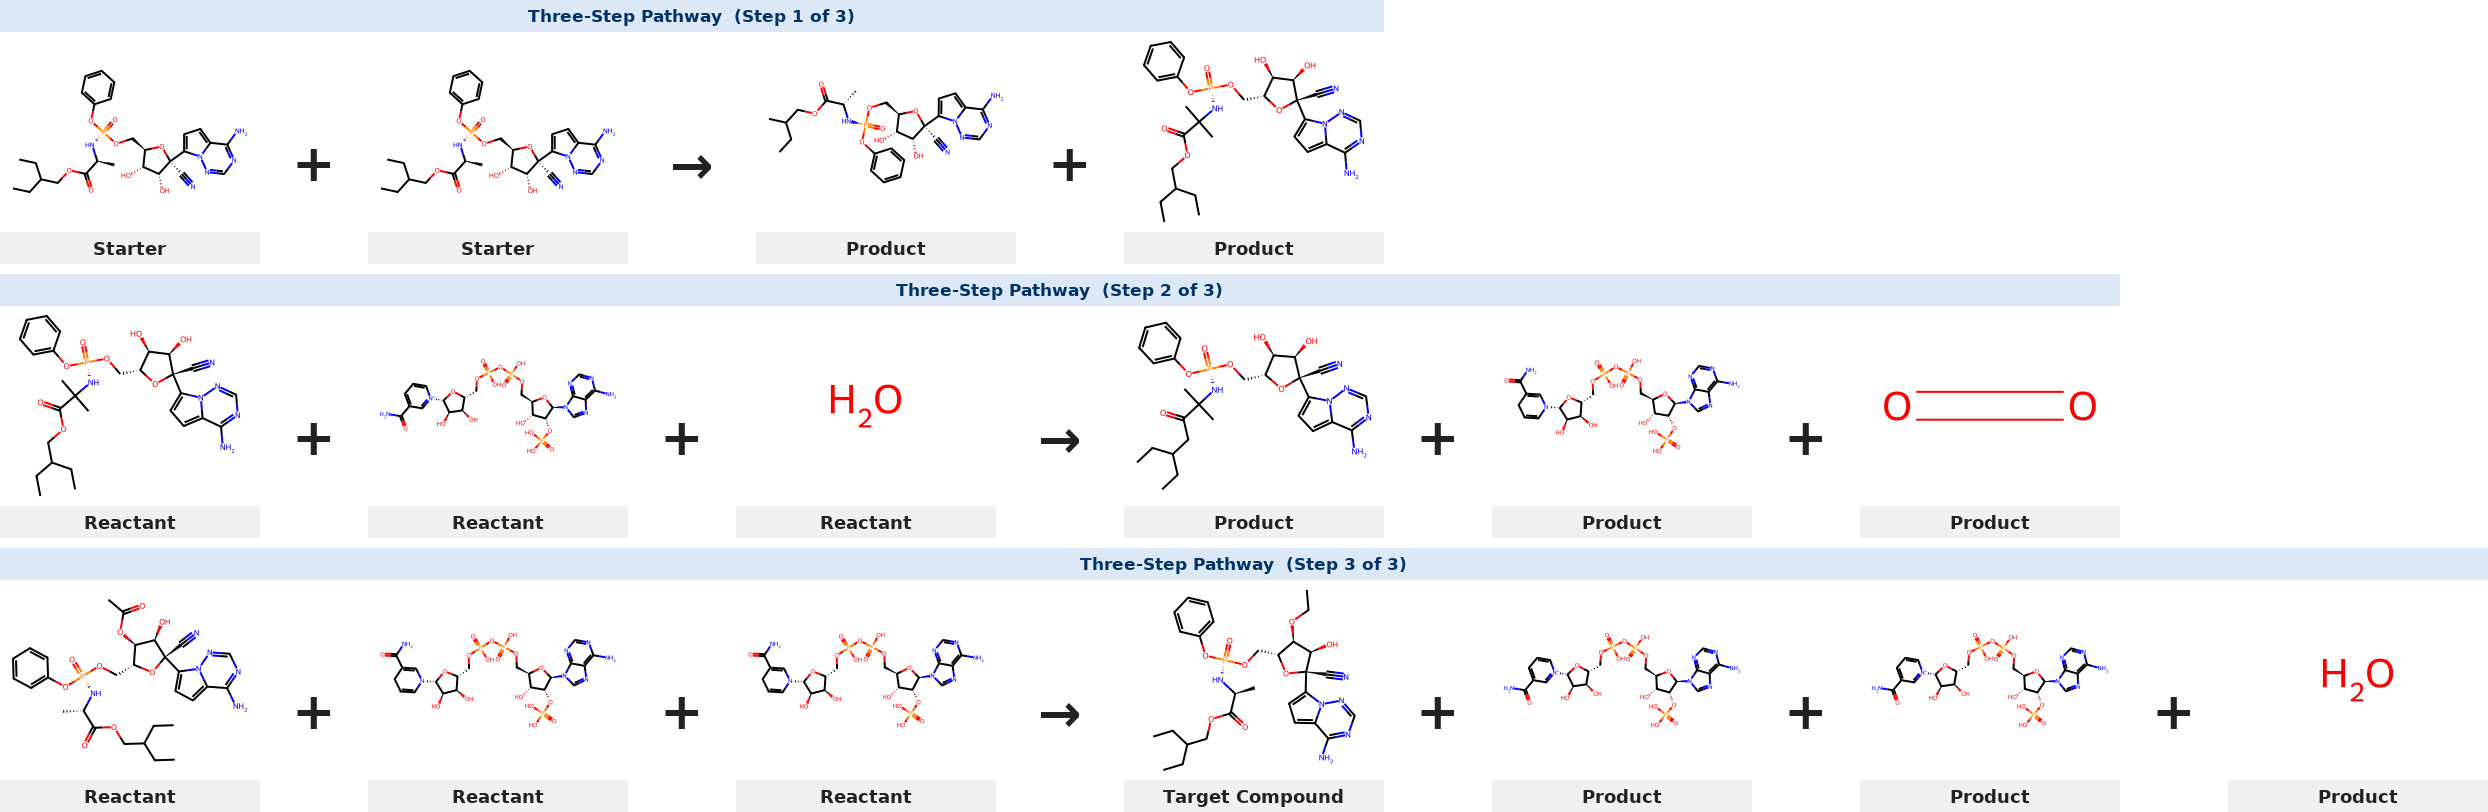

Saved: RemdesivirOnly_gen2_step3_pathway3.png  |  RemdesivirOnly_gen2_step3_pathway3.pdf


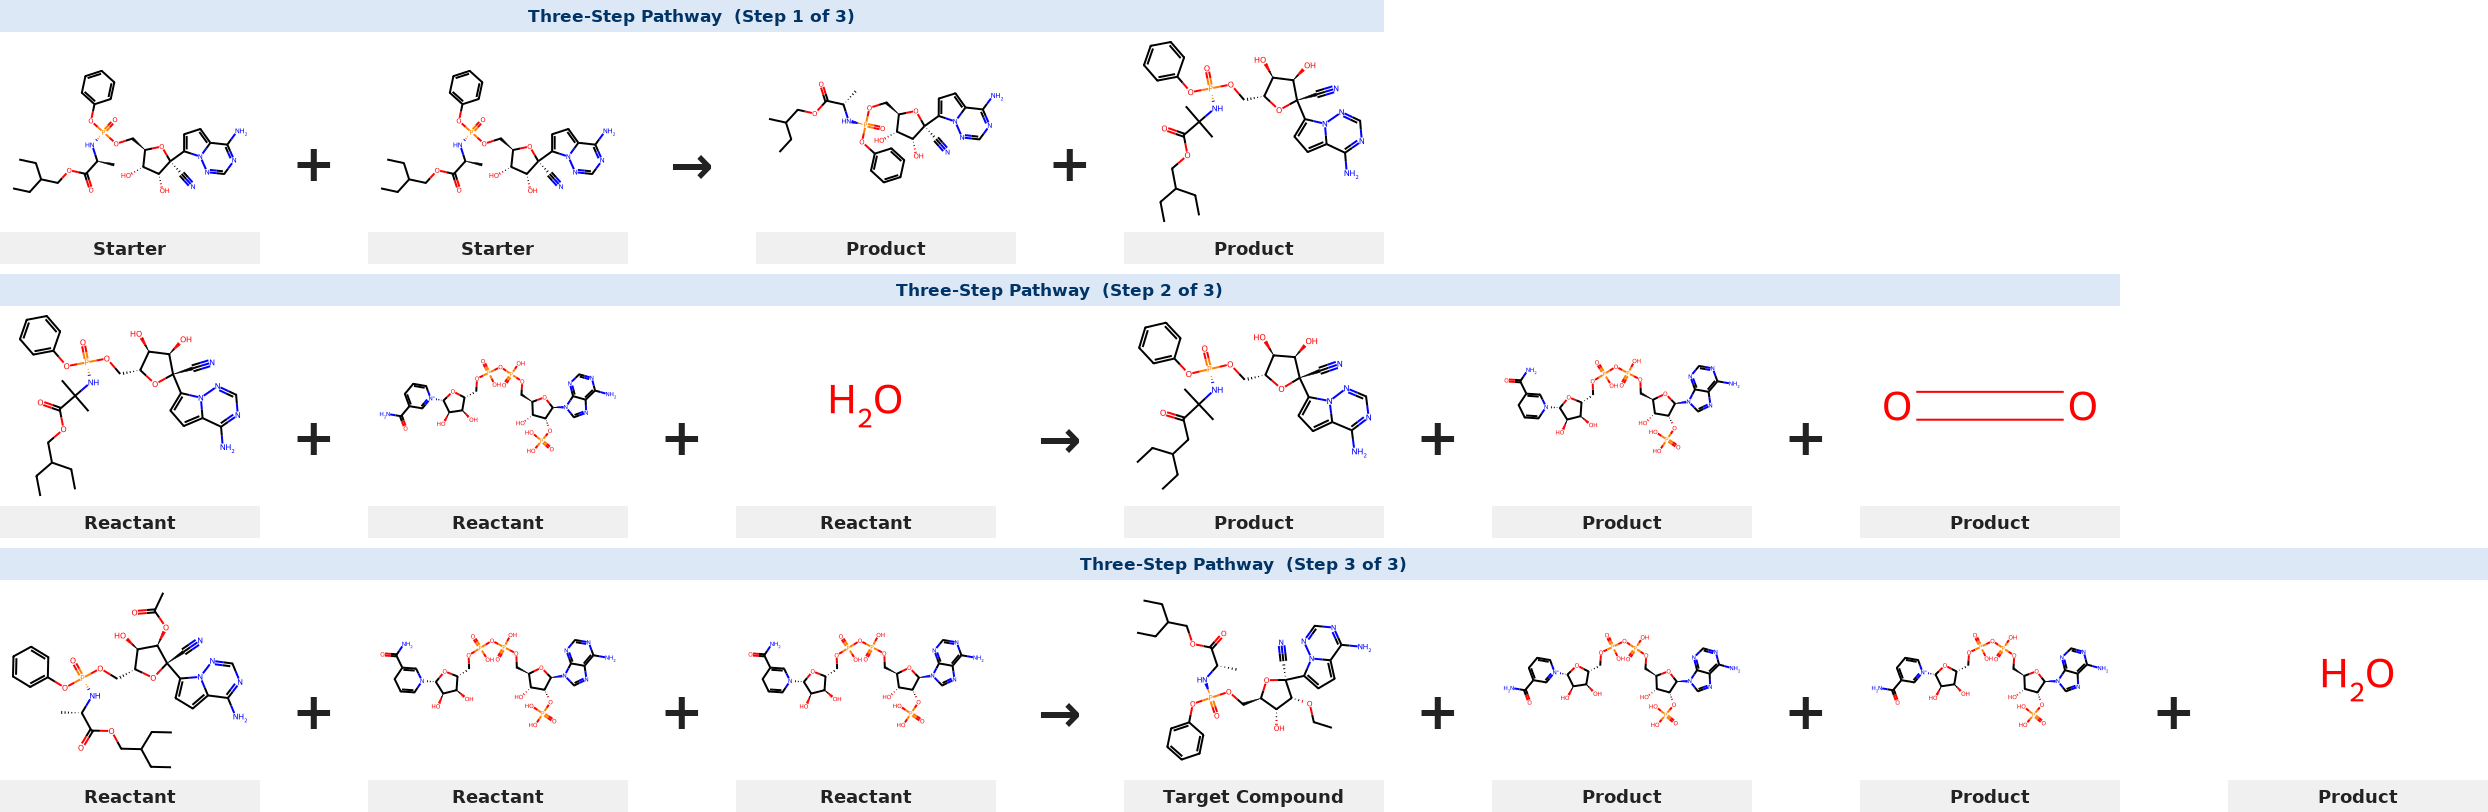


Total pathway figures saved: 9


In [19]:
molSize      = (260, 200)
sepWidth     = 80
stepBannerH  = 32
stepGap      = 10
depthWords   = {1: "One-Step", 2: "Two-Step", 3: "Three-Step"}


def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

fontSep   = loadFont(52)
fontLabel = loadFont(18)
fontStep  = loadFont(17)


def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")


def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bb    = draw.textbbox((0, 0), text, font=font)
        textW = bb[2] - bb[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)


def getMolLabel(canon, canonStarterSet, genuineProductSet, isLastStep, isProductSide):
    if not isProductSide:
        return "Starter" if canon in canonStarterSet else "Reactant"
    if isProductSide and canon in genuineProductSet and isLastStep:
        return "Target Compound"
    return "Product"


def makeLabeledMolImage(smi, label):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg = rdkitImageToPil(Draw.MolToImage(mol, size=molSize))
    banner = Image.new("RGB", (molImg.width, 32), "#f0f0f0")
    centeredText(ImageDraw.Draw(banner), label, molImg.width, 6, fontLabel, "#222222")
    out = Image.new("RGB", (molImg.width, molImg.height + banner.height), "white")
    out.paste(molImg, (0, 0))
    out.paste(banner, (0, molImg.height))
    return out


def makeSeparatorImage(text, height, width=80):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bb     = draw.textbbox((0, 0), text, font=fontSep)
        tw, th = bb[2] - bb[0], bb[3] - bb[1]
    except Exception:
        tw, th = 30, 50
    draw.text(((width - tw) // 2, (height - th) // 2), text, fill="#222222", font=fontSep)
    return img


def renderReactionStep(rxnIdx, reactionDF, canonStarterSet, genuineProductSet,
                       canonHelperSet, isLastStep, stepLabel):
    row = reactionDF.loc[rxnIdx]

    reactantSmis = splitMoleculeString(row["reactants"])
    productSmis  = splitMoleculeString(row["products"])

    reactantSmis = (
        [s for s in reactantSmis if canonSmiles(s) in canonStarterSet] +
        [s for s in reactantSmis if canonSmiles(s) not in canonStarterSet]
    )
    productSmis = (
        [s for s in productSmis if canonSmiles(s) in genuineProductSet] +
        [s for s in productSmis if canonSmiles(s) not in genuineProductSet]
    )

    reactantImgs = [
        img for img in [
            makeLabeledMolImage(
                s,
                getMolLabel(canonSmiles(s), canonStarterSet, genuineProductSet,
                            isLastStep, isProductSide=False),
            ) for s in reactantSmis
        ] if img is not None
    ]
    productImgs = [
        img for img in [
            makeLabeledMolImage(
                s,
                getMolLabel(canonSmiles(s), canonStarterSet, genuineProductSet,
                            isLastStep, isProductSide=True),
            ) for s in productSmis
        ] if img is not None
    ]

    if not reactantImgs or not productImgs:
        return None

    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 14
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=sepWidth))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=sepWidth))

    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    rxnRow = Image.new("RGB", (totalW, maxH), "white")
    x      = 0
    for part in parts:
        rxnRow.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap

    stepBanner = Image.new("RGB", (totalW, stepBannerH), "#dce8f5")
    centeredText(ImageDraw.Draw(stepBanner), stepLabel, totalW,
                 (stepBannerH - 20) // 2, fontStep, "#003366")

    panel = Image.new("RGB", (totalW, stepBannerH + rxnRow.height), "white")
    panel.paste(stepBanner, (0, 0))
    panel.paste(rxnRow,     (0, stepBannerH))
    return panel


def stackStepPanels(panels):
    if not panels:
        return None
    w      = max(p.width for p in panels)
    totalH = sum(p.height for p in panels) + stepGap * (len(panels) - 1)
    canvas = Image.new("RGB", (w, totalH), "white")
    y = 0
    for p in panels:
        canvas.paste(p, (0, y))
        y += p.height + stepGap
    return canvas


def findPathwayChains(reactionDF, canonStarterSet, genuineProductSet,
                      canonHelperSet, maxDepth=3, maxPerDepth=3):
    """
    Exhaustive BFS with no frontier cap. Safe because DORAnet ran a bounded
    3-step expansion, so the reaction network is finite and the BFS is
    guaranteed to terminate.
    """
    molToRxnIdxs = defaultdict(list)
    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            c = canonSmiles(smi)
            if c not in canonHelperSet:
                molToRxnIdxs[c].append(idx)

    def getNonHelperProducts(rxnIdx):
        row = reactionDF.loc[rxnIdx]
        return frozenset(
            canonSmiles(s) for s in splitMoleculeString(row["products"])
            if canonSmiles(s) not in canonHelperSet
        )

    pathways = {d: [] for d in range(1, maxDepth + 1)}
    queue    = deque()

    for starterCanon in canonStarterSet:
        for rxnIdx in molToRxnIdxs.get(starterCanon, []):
            products = getNonHelperProducts(rxnIdx)
            chain    = (rxnIdx,)
            if products & genuineProductSet and len(pathways[1]) < maxPerDepth:
                pathways[1].append(chain)
            if maxDepth > 1:
                queue.append((chain, products, frozenset({rxnIdx})))

    while queue:
        chain, availMols, visitedRxns = queue.popleft()
        depth = len(chain)

        if depth >= maxDepth:
            continue

        if all(len(pathways[d]) >= maxPerDepth for d in range(depth + 1, maxDepth + 1)):
            continue

        for mol in availMols:
            for rxnIdx in molToRxnIdxs.get(mol, []):
                if rxnIdx in visitedRxns:
                    continue

                products  = getNonHelperProducts(rxnIdx)
                newChain  = chain + (rxnIdx,)
                newDepth  = len(newChain)

                if products & genuineProductSet and len(pathways[newDepth]) < maxPerDepth:
                    pathways[newDepth].append(newChain)

                if newDepth < maxDepth:
                    queue.append((newChain, products, visitedRxns | {rxnIdx}))

    return pathways


genuineProductSet = set(generatedCompoundsDF["Canonical_SMILES"].dropna().unique())

print("Searching for 1-step, 2-step, and 3-step pathway chains...")
pathwaysByDepth = findPathwayChains(
    reactionDF,
    canonStarterSet,
    genuineProductSet,
    canonHelperSet,
)
for d, chains in pathwaysByDepth.items():
    print(f"  {d}-step pathways found: {len(chains)}")

savedFiles = []

for depth in range(1, 4):
    chains = pathwaysByDepth[depth]
    if not chains:
        print(f"\nNo {depth}-step pathways found.")
        continue

    for pIdx, chain in enumerate(chains):
        stepPanels = []
        totalSteps = len(chain)

        for stepIdx, rxnIdx in enumerate(chain):
            isLastStep = (stepIdx == totalSteps - 1)
            stepLabel  = (
                f"{depthWords[totalSteps]} Pathway  "
                f"(Step {stepIdx + 1} of {totalSteps})"
            )
            panel = renderReactionStep(
                rxnIdx, reactionDF, canonStarterSet, genuineProductSet,
                canonHelperSet, isLastStep, stepLabel,
            )
            if panel is not None:
                stepPanels.append(panel)

        pathwayImg = stackStepPanels(stepPanels)
        if pathwayImg is None:
            continue

        baseName = f"{fileNamePrefix}_step{depth}_pathway{pIdx + 1}"
        pngPath  = f"{baseName}.png"
        pdfPath  = f"{baseName}.pdf"

        pathwayImg.save(pngPath, format="PNG", dpi=(600, 600))
        pathwayImg.save(pdfPath, format="PDF", resolution=600)
        savedFiles.append((pngPath, pdfPath))

        print(f"Saved: {pngPath}  |  {pdfPath}")
        display(pathwayImg)

print(f"\nTotal pathway figures saved: {len(savedFiles)}")